# Scenario Search and Filtering

This notebook provides tools to search for specific driving scenarios in the CARLA-NavSim dataset.

## Contents
1. Setup and imports
2. Scenario search functions
3. Predefined scenario searches
4. Custom scenario filtering
5. Scenario visualization and analysis

## 1. Setup and Imports

In [7]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pickle
import gzip
import torch
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Define paths
base_cache_dir = Path("/workspace/navsim_workspace/exp/training_cache/")

# Get all sequences
sequences = sorted([d for d in base_cache_dir.iterdir() if d.is_dir()])
print(f"Found {len(sequences)} sequences to search")

Found 1192 sequences to search


## 2. Scenario Search Functions

In [8]:
def load_token_data(token_path):
    """Load features and targets for a single token."""
    try:
        with gzip.open(token_path / "transfuser_feature.gz", 'rb') as f:
            features = pickle.load(f)
        with gzip.open(token_path / "transfuser_target.gz", 'rb') as f:
            targets = pickle.load(f)
        return features, targets
    except Exception as e:
        return None, None

def extract_scenario_info(features, targets):
    """Extract key information from a frame."""
    status = features['status_feature'].numpy()
    traj = targets['trajectory'].numpy()
    agent_states = targets['agent_states'].numpy()
    agent_labels = targets['agent_labels'].numpy()
    bev_map = targets['bev_semantic_map'].numpy()
    
    # Basic info - FIXED INDICES
    # Status feature format: [left, straight, right, unknown, vx, vy, ax, ay]
    vx, vy = status[4], status[5]
    ax, ay = status[6], status[7]
    speed = np.sqrt(vx**2 + vy**2)
    accel_mag = np.sqrt(ax**2 + ay**2)
    
    # Command - FIXED INDICES AND NAMES
    cmd_idx = np.argmax(status[0:4])
    cmd_names = ['LEFT', 'STRAIGHT', 'RIGHT', 'UNKNOWN']
    command = cmd_names[cmd_idx]
    
    # Trajectory analysis
    traj_length = np.sum(np.linalg.norm(np.diff(traj[:, :2], axis=0), axis=1))
    traj_curvature = np.std(traj[:, 1])  # Simple curvature measure
    heading_change = np.abs(traj[-1, 2] - traj[0, 2])
    
    # Agent analysis
    num_agents = np.sum(agent_labels)
    if num_agents > 0:
        valid_agents = agent_states[agent_labels]
        agent_distances = np.sqrt(valid_agents[:, 0]**2 + valid_agents[:, 1]**2)
        closest_agent = np.min(agent_distances)
    else:
        closest_agent = float('inf')
    
    # BEV analysis
    unique_classes, counts = np.unique(bev_map, return_counts=True)
    bev_distribution = dict(zip(unique_classes, counts))
    
    return {
        'speed': speed,
        'acceleration': accel_mag,
        'vx': vx,
        'vy': vy,
        'ax': ax,
        'ay': ay,
        'command': command,
        'trajectory_length': traj_length,
        'trajectory_curvature': traj_curvature,
        'heading_change': heading_change,
        'num_agents': num_agents,
        'closest_agent': closest_agent,
        'bev_distribution': bev_distribution
    }

## 3. Predefined Scenario Searches

In [9]:
def find_scenarios(scenario_type, num_examples=5, max_sequences=20, max_tokens_per_seq=10):
    """Find specific scenario types in the dataset."""
    
    scenario_filters = {
        'turn': lambda info: info['command'] in ['LEFT', 'RIGHT'],
        'stop': lambda info: info['command'] == 'UNKNOWN' or info['speed'] < 0.5,
        'high_speed': lambda info: info['speed'] > 10.0,
        'crowded': lambda info: info['num_agents'] > 5,
        'close_encounter': lambda info: info['closest_agent'] < 5.0,
        'sharp_turn': lambda info: info['heading_change'] > 0.5,
        'hard_brake': lambda info: info['ax'] < -2.0,
        'acceleration': lambda info: info['ax'] > 2.0
    }
    
    if scenario_type not in scenario_filters:
        print(f"Unknown scenario type: {scenario_type}")
        print(f"Available types: {list(scenario_filters.keys())}")
        return []
    
    filter_func = scenario_filters[scenario_type]
    found_scenarios = []
    
    print(f"Searching for '{scenario_type}' scenarios...")
    
    for seq_idx, seq_path in enumerate(sequences[:max_sequences]):
        tokens = sorted([d for d in seq_path.iterdir() if d.is_dir()])
        
        for token_idx, token_path in enumerate(tokens[:max_tokens_per_seq]):
            features, targets = load_token_data(token_path)
            if features is None:
                continue
            
            info = extract_scenario_info(features, targets)
            
            if filter_func(info):
                found_scenarios.append({
                    'sequence': seq_path.name,
                    'token': token_path.name,
                    'token_idx': token_idx,
                    'info': info
                })
                
                if len(found_scenarios) >= num_examples:
                    break
        
        if len(found_scenarios) >= num_examples:
            break
    
    print(f"\nFound {len(found_scenarios)} '{scenario_type}' scenarios")
    return found_scenarios

# Search for different scenario types
turn_scenarios = find_scenarios('turn', num_examples=3)
stop_scenarios = find_scenarios('stop', num_examples=3)
crowded_scenarios = find_scenarios('crowded', num_examples=3)

Searching for 'turn' scenarios...

Found 3 'turn' scenarios
Searching for 'stop' scenarios...

Found 3 'stop' scenarios
Searching for 'crowded' scenarios...

Found 3 'crowded' scenarios


## 4. Custom Scenario Filtering

In [10]:
def custom_scenario_search(filter_func, description="custom", 
                          num_examples=5, max_sequences=20):
    """Search for scenarios using a custom filter function."""
    found_scenarios = []
    
    print(f"Searching for {description} scenarios...")
    
    for seq_path in sequences[:max_sequences]:
        tokens = sorted([d for d in seq_path.iterdir() if d.is_dir()])
        
        for token_idx, token_path in enumerate(tokens[:10]):
            features, targets = load_token_data(token_path)
            if features is None:
                continue
            
            info = extract_scenario_info(features, targets)
            
            if filter_func(info):
                found_scenarios.append({
                    'sequence': seq_path.name,
                    'token': token_path.name,
                    'token_idx': token_idx,
                    'info': info
                })
                
                if len(found_scenarios) >= num_examples:
                    return found_scenarios
    
    return found_scenarios

# Example: Find scenarios with moderate speed left turns
def moderate_left_turn(info):
    return (info['command'] == 'LEFT' and 
            3.0 < info['speed'] < 8.0 and
            info['trajectory_curvature'] > 0.1)

left_turn_scenarios = custom_scenario_search(
    moderate_left_turn, 
    description="moderate speed left turn",
    num_examples=3
)

# Example: Find congested intersections
def congested_intersection(info):
    return (info['num_agents'] > 3 and
            info['speed'] < 5.0 and
            info['bev_distribution'].get(1.0, 0) > 5000)  # Lots of road pixels

intersection_scenarios = custom_scenario_search(
    congested_intersection,
    description="congested intersection",
    num_examples=3
)

Searching for moderate speed left turn scenarios...


Searching for congested intersection scenarios...


## 5. Scenario Visualization and Analysis


=== Turn Scenario Example ===


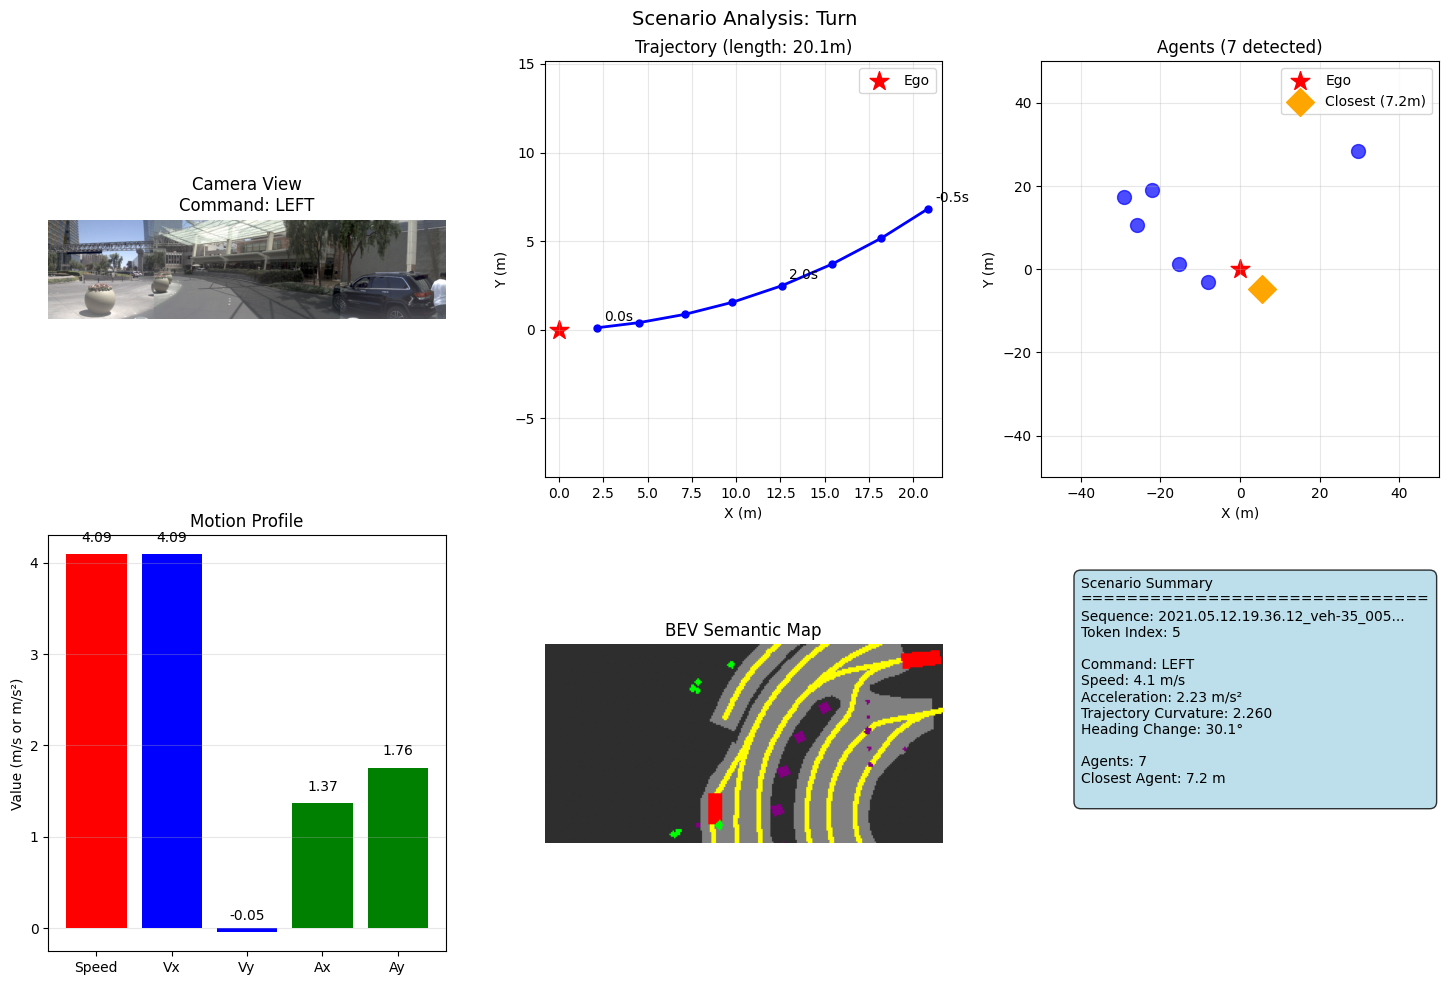


=== Crowded Scenario Example ===


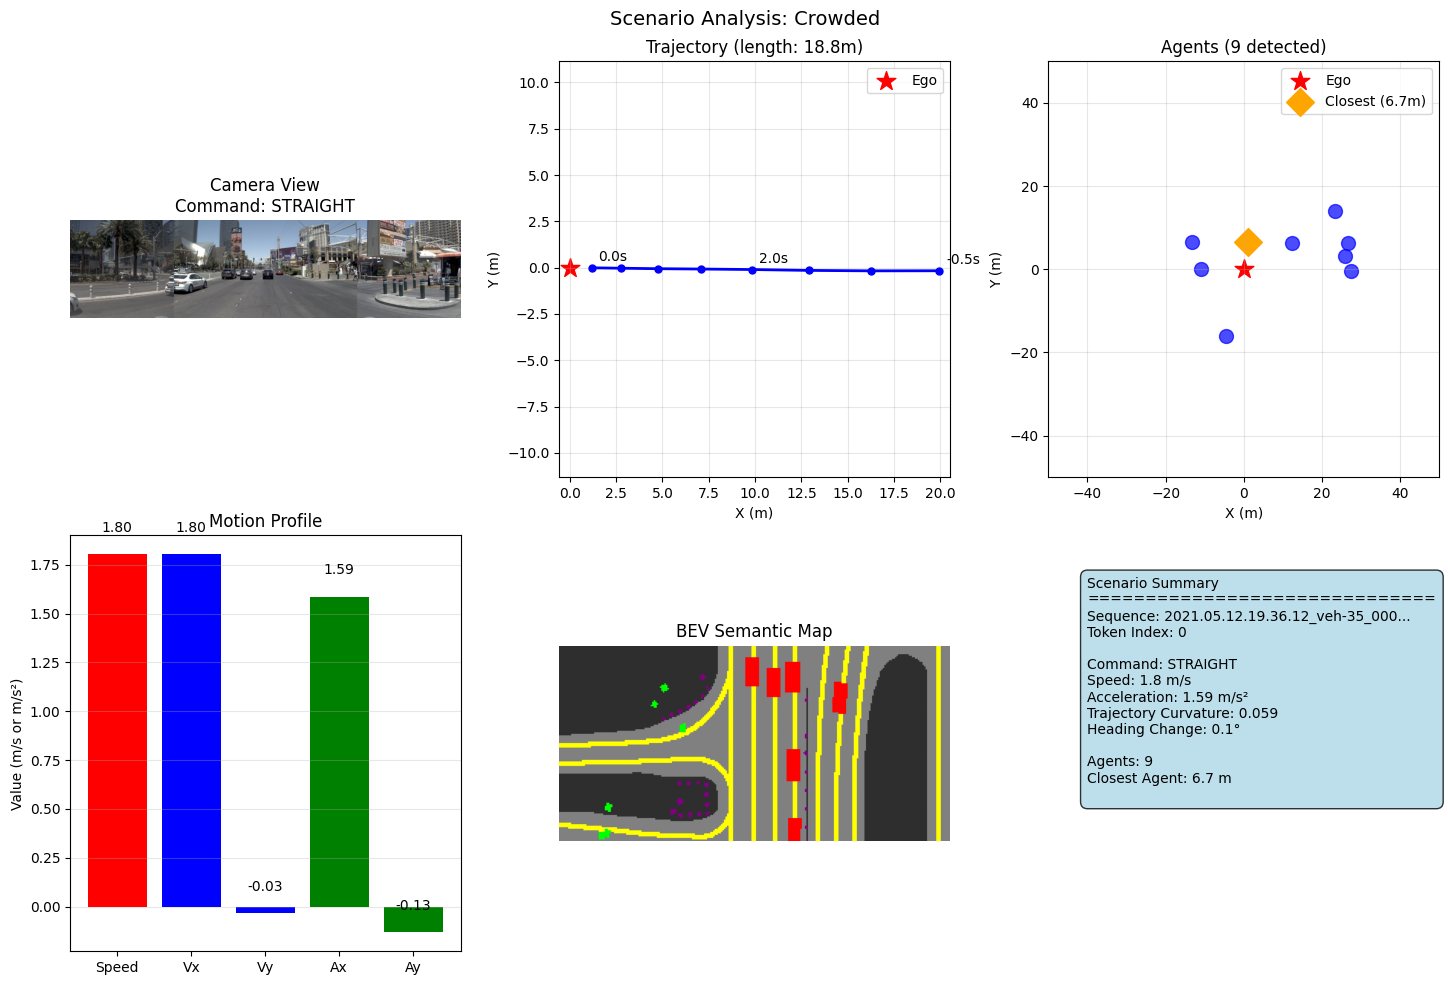

In [11]:
def visualize_scenario(scenario, figsize=(15, 10)):
    """Detailed visualization of a specific scenario."""
    seq_path = base_cache_dir / scenario['sequence']
    token_path = seq_path / scenario['token']
    
    features, targets = load_token_data(token_path)
    if features is None:
        print("Failed to load scenario data")
        return
    
    info = scenario['info']
    
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    
    # 1. Camera view
    ax1 = axes[0, 0]
    camera_img = features['camera_feature'].numpy().transpose(1, 2, 0)
    ax1.imshow(camera_img)
    ax1.set_title(f"Camera View\nCommand: {info['command']}")
    ax1.axis('off')
    
    # 2. Trajectory with analysis
    ax2 = axes[0, 1]
    traj = targets['trajectory'].numpy()
    ax2.plot(traj[:, 0], traj[:, 1], 'b.-', markersize=10, linewidth=2)
    ax2.scatter(0, 0, c='red', s=200, marker='*', label='Ego')
    
    # Add trajectory annotations
    for i in [0, len(traj)//2, -1]:
        ax2.annotate(f'{i*0.5:.1f}s', 
                    (traj[i, 0], traj[i, 1]),
                    xytext=(5, 5), textcoords='offset points')
    
    ax2.set_xlabel('X (m)')
    ax2.set_ylabel('Y (m)')
    ax2.set_title(f'Trajectory (length: {info["trajectory_length"]:.1f}m)')
    ax2.grid(True, alpha=0.3)
    ax2.axis('equal')
    ax2.legend()
    
    # 3. Agent visualization
    ax3 = axes[0, 2]
    agent_states = targets['agent_states'].numpy()
    agent_labels = targets['agent_labels'].numpy()
    valid_agents = agent_states[agent_labels]
    
    ax3.scatter(0, 0, c='red', s=200, marker='*', label='Ego')
    
    if len(valid_agents) > 0:
        ax3.scatter(valid_agents[:, 0], valid_agents[:, 1], 
                   c='blue', s=100, alpha=0.7)
        
        # Highlight closest agent
        distances = np.sqrt(valid_agents[:, 0]**2 + valid_agents[:, 1]**2)
        closest_idx = np.argmin(distances)
        ax3.scatter(valid_agents[closest_idx, 0], valid_agents[closest_idx, 1],
                   c='orange', s=200, marker='D', label=f'Closest ({distances[closest_idx]:.1f}m)')
    
    ax3.set_xlim(-50, 50)
    ax3.set_ylim(-50, 50)
    ax3.set_xlabel('X (m)')
    ax3.set_ylabel('Y (m)')
    ax3.set_title(f'Agents ({info["num_agents"]} detected)')
    ax3.grid(True, alpha=0.3)
    ax3.legend()
    
    # 4. Speed and acceleration profile
    ax4 = axes[1, 0]
    categories = ['Speed', 'Vx', 'Vy', 'Ax', 'Ay']
    values = [info['speed'], info['vx'], info['vy'], info['ax'], info['ay']]
    colors = ['red', 'blue', 'blue', 'green', 'green']
    
    bars = ax4.bar(categories, values, color=colors)
    ax4.set_ylabel('Value (m/s or m/s²)')
    ax4.set_title('Motion Profile')
    ax4.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bar, val in zip(bars, values):
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.2f}', ha='center', va='bottom')
    
    # 5. BEV semantic map
    ax5 = axes[1, 1]
    bev_map = targets['bev_semantic_map'].numpy()
    
    category_colors = {
        0: '#2E2E2E', 1: '#808080', 2: '#FFA500', 3: '#FFFF00',
        4: '#800080', 5: '#FF0000', 6: '#00FF00'
    }
    colors_list = [category_colors[i] for i in range(7)]
    cmap = mcolors.ListedColormap(colors_list)
    norm = mcolors.BoundaryNorm(np.arange(8) - 0.5, 7)
    
    im = ax5.imshow(bev_map, cmap=cmap, norm=norm, origin='lower')
    ax5.set_title('BEV Semantic Map')
    ax5.axis('off')
    
    # 6. Scenario summary
    ax6 = axes[1, 2]
    ax6.axis('off')
    
    summary_text = f"Scenario Summary\n" + "="*30 + "\n"
    summary_text += f"Sequence: {scenario['sequence'][:30]}...\n"
    summary_text += f"Token Index: {scenario['token_idx']}\n\n"
    summary_text += f"Command: {info['command']}\n"
    summary_text += f"Speed: {info['speed']:.1f} m/s\n"
    summary_text += f"Acceleration: {info['acceleration']:.2f} m/s²\n"
    summary_text += f"Trajectory Curvature: {info['trajectory_curvature']:.3f}\n"
    summary_text += f"Heading Change: {np.rad2deg(info['heading_change']):.1f}°\n\n"
    summary_text += f"Agents: {info['num_agents']}\n"
    summary_text += f"Closest Agent: {info['closest_agent']:.1f} m\n"
    
    ax6.text(0.1, 0.9, summary_text, transform=ax6.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle="round,pad=0.5", facecolor='lightblue', alpha=0.8))
    
    plt.suptitle(f"Scenario Analysis: {scenario_type}", fontsize=14)
    plt.tight_layout()
    plt.show()

# Visualize example scenarios
if turn_scenarios:
    print("\n=== Turn Scenario Example ===")
    scenario_type = "Turn"
    visualize_scenario(turn_scenarios[0])

if crowded_scenarios:
    print("\n=== Crowded Scenario Example ===")
    scenario_type = "Crowded"
    visualize_scenario(crowded_scenarios[0])

Analyzing scenario distribution across 30 sequences...
  Processing sequence 0...
  Processing sequence 10...
  Processing sequence 20...


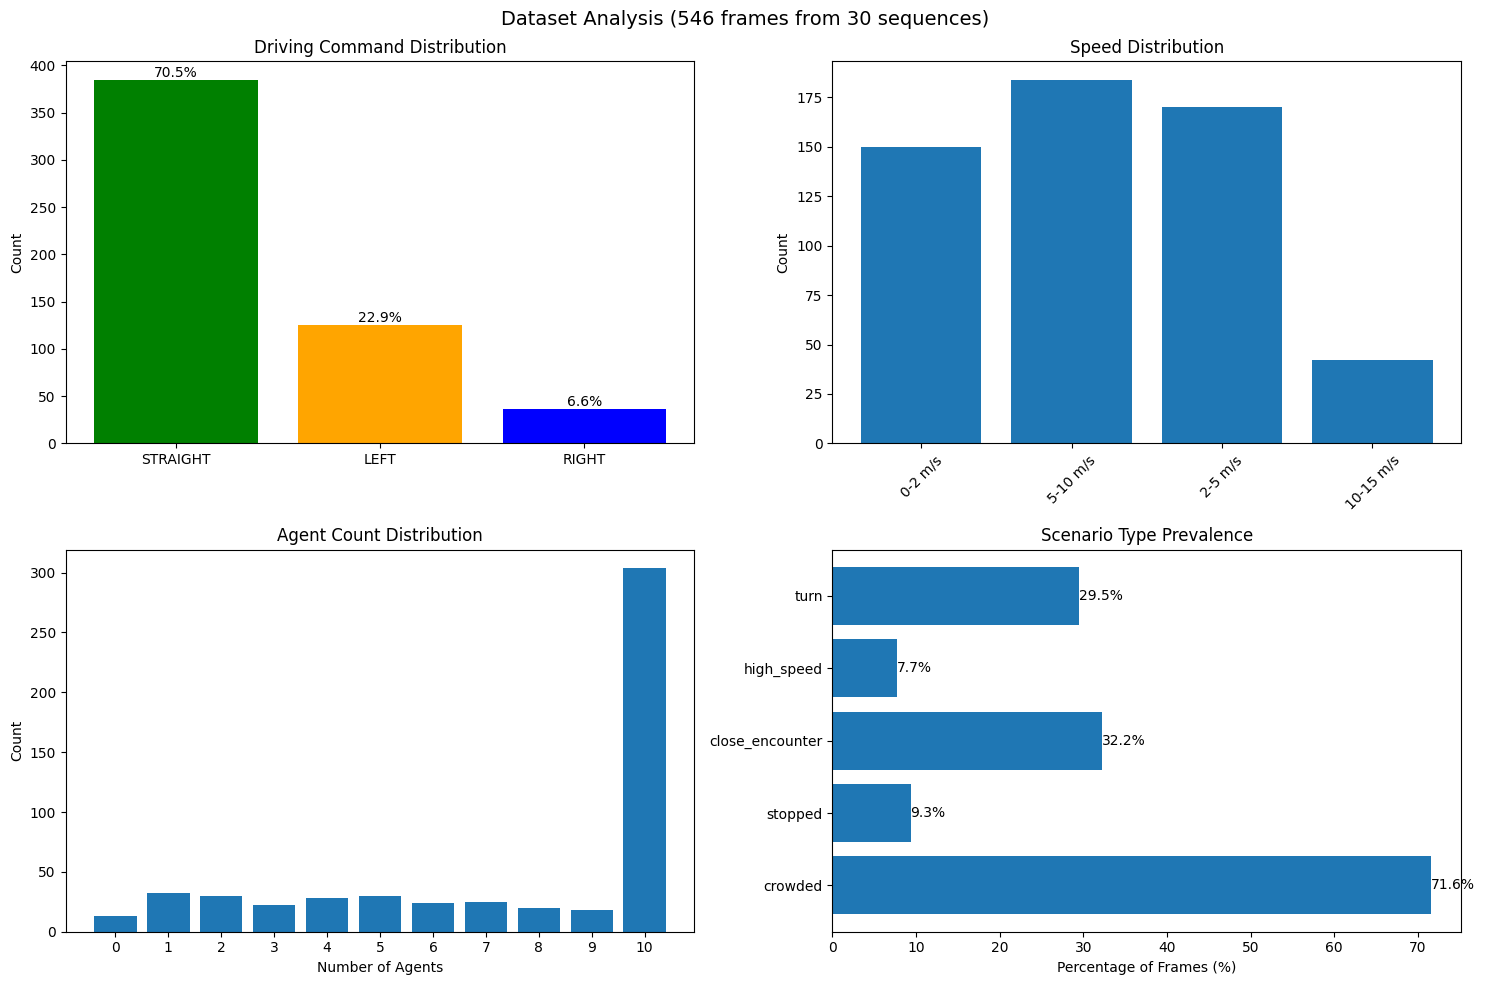


Analyzed 546 total frames


In [12]:
def analyze_scenario_distribution(max_sequences=50, max_tokens_per_seq=20):
    """Analyze the distribution of different scenarios in the dataset."""
    
    scenario_counts = defaultdict(int)
    command_counts = defaultdict(int)
    speed_bins = [0, 2, 5, 10, 15, 20, 100]
    speed_histogram = defaultdict(int)
    agent_histogram = defaultdict(int)
    
    total_frames = 0
    
    print(f"Analyzing scenario distribution across {max_sequences} sequences...")
    
    for seq_idx, seq_path in enumerate(sequences[:max_sequences]):
        if seq_idx % 10 == 0:
            print(f"  Processing sequence {seq_idx}...")
        
        tokens = sorted([d for d in seq_path.iterdir() if d.is_dir()])
        
        for token_path in tokens[:max_tokens_per_seq]:
            features, targets = load_token_data(token_path)
            if features is None:
                continue
            
            info = extract_scenario_info(features, targets)
            total_frames += 1
            
            # Count commands
            command_counts[info['command']] += 1
            
            # Speed distribution
            for i in range(len(speed_bins) - 1):
                if speed_bins[i] <= info['speed'] < speed_bins[i+1]:
                    speed_histogram[f"{speed_bins[i]}-{speed_bins[i+1]} m/s"] += 1
                    break
            
            # Agent count distribution
            agent_histogram[min(info['num_agents'], 10)] += 1
            
            # Scenario types
            if info['command'] in ['LEFT', 'RIGHT']:
                scenario_counts['turn'] += 1
            if info['speed'] < 0.5:
                scenario_counts['stopped'] += 1
            if info['speed'] > 10.0:
                scenario_counts['high_speed'] += 1
            if info['num_agents'] > 5:
                scenario_counts['crowded'] += 1
            if info['closest_agent'] < 5.0:
                scenario_counts['close_encounter'] += 1
    
    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Command distribution
    ax1 = axes[0, 0]
    commands = list(command_counts.keys())
    counts = list(command_counts.values())
    # Map command names to colors
    color_map = {'LEFT': 'orange', 'STRAIGHT': 'green', 'RIGHT': 'blue', 'UNKNOWN': 'red'}
    colors = [color_map.get(cmd, 'gray') for cmd in commands]
    ax1.bar(commands, counts, color=colors)
    ax1.set_ylabel('Count')
    ax1.set_title('Driving Command Distribution')
    for i, (cmd, count) in enumerate(zip(commands, counts)):
        ax1.text(i, count, f'{100*count/total_frames:.1f}%', 
                ha='center', va='bottom')
    
    # 2. Speed distribution
    ax2 = axes[0, 1]
    speed_ranges = list(speed_histogram.keys())
    speed_counts = list(speed_histogram.values())
    ax2.bar(range(len(speed_ranges)), speed_counts)
    ax2.set_xticks(range(len(speed_ranges)))
    ax2.set_xticklabels(speed_ranges, rotation=45)
    ax2.set_ylabel('Count')
    ax2.set_title('Speed Distribution')
    
    # 3. Agent count distribution
    ax3 = axes[1, 0]
    agent_nums = sorted(agent_histogram.keys())
    agent_counts = [agent_histogram[n] for n in agent_nums]
    ax3.bar(agent_nums, agent_counts)
    ax3.set_xlabel('Number of Agents')
    ax3.set_ylabel('Count')
    ax3.set_title('Agent Count Distribution')
    ax3.set_xticks(agent_nums)
    
    # 4. Scenario type prevalence
    ax4 = axes[1, 1]
    scenario_types = list(scenario_counts.keys())
    scenario_vals = list(scenario_counts.values())
    scenario_pcts = [100 * v / total_frames for v in scenario_vals]
    
    bars = ax4.barh(scenario_types, scenario_pcts)
    ax4.set_xlabel('Percentage of Frames (%)')
    ax4.set_title('Scenario Type Prevalence')
    
    for bar, pct in zip(bars, scenario_pcts):
        ax4.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
                f'{pct:.1f}%', ha='left', va='center')
    
    plt.suptitle(f'Dataset Analysis ({total_frames} frames from {max_sequences} sequences)', 
                fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print(f"\nAnalyzed {total_frames} total frames")
    return {
        'total_frames': total_frames,
        'command_counts': dict(command_counts),
        'scenario_counts': dict(scenario_counts),
        'speed_histogram': dict(speed_histogram),
        'agent_histogram': dict(agent_histogram)
    }

# Analyze dataset distribution
distribution_stats = analyze_scenario_distribution(max_sequences=30)

## Summary

This notebook provides comprehensive tools for:
1. Searching for specific driving scenarios
2. Creating custom scenario filters
3. Visualizing and analyzing individual scenarios
4. Understanding scenario distribution in the dataset

### Available Scenario Types
- **turn**: Left or right turn commands
- **stop**: Unknown command or very low speed (<0.5 m/s)
- **high_speed**: Speed > 10 m/s
- **crowded**: More than 5 detected agents
- **close_encounter**: Nearest agent < 5m
- **sharp_turn**: Large heading change
- **hard_brake**: Strong deceleration
- **acceleration**: Strong acceleration

### Custom Scenarios
You can create custom filters by combining conditions on:
- Speed, acceleration components
- Driving commands
- Trajectory properties
- Agent proximity and count
- BEV semantic distribution

### Next Steps
- For basic data exploration, see `01_data_loading_basics.ipynb`
- For temporal analysis, see `02_temporal_analysis.ipynb`